# **Responsi: Neural Style Transfer**

Nama : Rahman Nendhiarto

NIM  : 2200018315


 **Dilarang melakukan kecurangan dengan praktikan lain, apabila ditemukan kesamaan jawaban ataupun parameter maka responsi dianggap GAGAL!!!**

# **Neural Style Transfer**
For example, if given an input image:

<img src="https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg" width="500px"/>

and given a painting by Kandinsky where we want to transfer the style:

<img src="https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg" width="500px"/>


Now, what would it look like if Kandinsky decided to paint the picture of this Dog exclusively with this style? Something like this?

<img src="https://tensorflow.org/tutorials/generative/images/stylized-image.png" style="width: 500px;"/>

# **Soal Praktik 1**


## **1. Mounting Google Drive**

In [ ]:
from google.colab import drive

# mounting dataset from gdrive
drive.mount('/content/gdrive', force_remount=True)

# this is the location of your image data
root_path = 'gdrive/My Drive/Deep Learning Labs/Responsi/Dataset Responsi/Dataset Responsi Deep Learning/'

# show the path
print("Path root:", root_path)

Mounted at /content/gdrive
Path root: gdrive/My Drive/Deep Learning Labs/Responsi/Dataset Responsi/Dataset Responsi Deep Learning/


## **2. Import Library**

In [ ]:
import IPython.display as display

import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image

## **3. Definisikan Function Untuk Load Dan Display Data Gambar**

In [ ]:
# convert tensor to image
def tensor_to_image(tensor):
    tensor = tensor*255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]
    return PIL.Image.fromarray(tensor)

def load_img(path_to_img):
    max_dim = 512
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

def imshow(image, title=None):
    if len(image.shape) > 3:
        image = tf.squeeze(image, axis=0)

    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')

## **4. Baca Data Gambar**

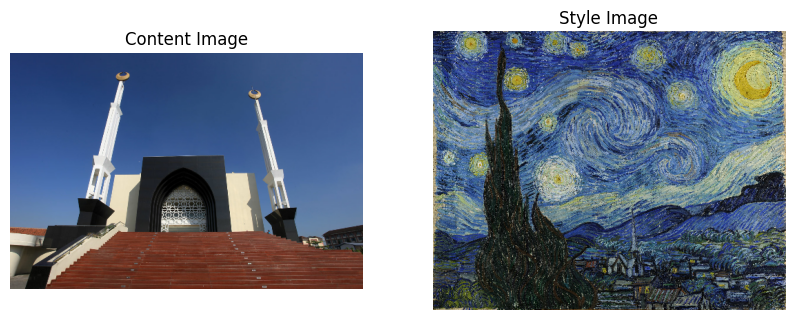

In [ ]:
content_path = os.path.join(root_path, 'content.jpg')
style_path = os.path.join(root_path, 'style.jpg')

content_image = load_img(content_path)
style_image = load_img(style_path)

plt.figure(figsize=(10, 15))
plt.subplot(1, 2, 1)
imshow(content_image, 'Content Image')
plt.subplot(1, 2, 2)
imshow(style_image, 'Style Image')



---

# **FIX ME 1: Panggil Model VGG16 untuk Neural Style Transfer [Score: 5]**

Gunakan parameter :
*   include_top=False
*   weights='imagenet'

Referensi : https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16

In [ ]:
# check the name of each layers on VGG16
vgg = tf.keras.applications.vgg16.VGG16(include_top=False, weights='imagenet')
vgg.summary()
print("Number of layers:", len(vgg.layers))


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Number of layers: 19


# **FIX ME 2: Ubah Content dan Style Layers [Score: 10]**
Gunakan kombinasi 2 layers dari block_conv3 untuk content layers dan kombinasi 5 layers dari block_conv1 dan block_conv2 untuk style layers

**Contoh :**

**Content layers:**
*   block..._conv3
*   block..._conv3

**Style layers:**
*   block..._conv1
*   block..._conv2
*   block..._conv1
*   block..._conv2

**Dilarang melakukan kecurangan dengan praktikan lain, apabila ditemukan kesamaan jawaban ataupun parameter maka responsi dianggap GAGAL!!!**

In [ ]:
# define the content layers
content_layers = ['block5_conv2']

# define the style layers
style_layers = ['block1_conv1','block2_conv1','block4_conv1','block5_conv1']

# get the number of content and style layers
num_content_layers = len(content_layers)
num_style_layers = len(style_layers)

**Intermediate layers for style and content**

So why do these intermediate outputs within our pretrained image classification network allow us to define style and content representations?

At a high level, in order for a network to perform image classification (which this network has been trained to do), it must understand the image. This requires taking the raw image as input pixels and building an internal representation that converts the raw image pixels into a complex understanding of the features present within the image.

This is also a reason why convolutional neural networks are able to generalize well: they’re able to capture the invariances and defining features within classes (e.g. cats vs. dogs) that are agnostic to background noise and other nuisances. Thus, somewhere between where the raw image is fed into the model and the output classification label, the model serves as a complex feature extractor. By accessing intermediate layers of the model, you're able to describe the content and style of input images.

# **FIX ME 2: Ubah Backbone Model ke VGG16 [Score: 5]**
Ubah backbone model ke VGG16 untuk Neural Style Transfer dengan freeze layers bernilai False

Referensi : https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16

In [ ]:
# create a new model using all layers defined in the layer_names
def vgg_layers(layer_names):
    # creates a VGG model that returns a list of intermediate output values
    # load our VGG16 model. Load pretrained VGG, trained on ImageNet data
    vgg = tf.keras.applications.vgg16.VGG16(include_top=False, weights='imagenet')
    vgg.trainable = False

    # freeze the layers
    vgg.trainable = False

    # create a new model using all layers defined in the layer_names
    outputs = [vgg.get_layer(name).output for name in layer_names]

    # get all layers defined in the layer_names
    outputs = [vgg.get_layer(name).output for name in layer_names]

    # build the model
    model = tf.keras.Model([vgg.input], outputs)
    return model

**Calculate style**

The content of an image is represented by the values of the intermediate feature maps.

It turns out, the style of an image can be described by the means and correlations across the different feature maps. Calculate a Gram matrix that includes this information by taking the outer product of the feature vector with itself at each location, and averaging that outer product over all locations. This Gram matrix can be calculated for a particular layer as:

$$G^l_{cd} = \frac{\sum_{ij} F^l_{ijc}(x)F^l_{ijd}(x)}{IJ}$$

This can be implemented concisely using the `tf.linalg.einsum` function:

In [ ]:
# compute gram matrix
def gram_matrix(input_tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)
    input_shape = tf.shape(input_tensor)
    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
    return result/(num_locations)

# **FIX ME 3: Ubah Preprocessing Layer ke VGG16 [Score: 10]**
Ubah function call pada kode untuk menggunakan preprocessing input layer untuk model VGG16

Referensi : https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16

In [ ]:
# create a class for the model
class StyleContentModel(tf.keras.models.Model):
    # initialize attributes when created
    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()
        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)
        self.vgg.trainable = False

    # function to be executed when called
    def call(self, inputs):
        "Expects float input in [0,1]"
        inputs = inputs*255.0

        # use preprocessing layer for VGG16
        preprocessed_input = tf.keras.applications.vgg16.preprocess_input(inputs)

        # run the image through the model
        outputs = self.vgg(preprocessed_input)

        # get the style and content layers
        style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                            outputs[self.num_style_layers:])

        # compute gram matrix for style output
        style_outputs, content_outputs = (outputs[:self.num_style_layers],
                                            outputs[self.num_style_layers:])
        style_outputs = [gram_matrix(style_output)
                            for style_output in style_outputs]

        content_dict = {content_name: value
                        for content_name, value
                            in zip(self.content_layers, content_outputs)}

        style_dict = {style_name: value
                        for style_name, value
                            in zip(self.style_layers, style_outputs)}

        return {'content': content_dict, 'style': style_dict}

## **5. Build the Model**

In [ ]:
# call the class to build style extractor
extractor = StyleContentModel(style_layers, content_layers)

results = extractor(tf.constant(content_image))

print('Styles:')
for name, output in sorted(results['style'].items()):
    print("  ", name)
    print("    shape: ", output.numpy().shape)
    print("    min: ", output.numpy().min())
    print("    max: ", output.numpy().max())
    print("    mean: ", output.numpy().mean())
    print()

print("Contents:")
for name, output in sorted(results['content'].items()):
    print("  ", name)
    print("    shape: ", output.numpy().shape)
    print("    min: ", output.numpy().min())
    print("    max: ", output.numpy().max())
    print("    mean: ", output.numpy().mean())

Styles:
   block1_conv1
    shape:  (1, 64, 64)
    min:  0.013754165
    max:  17208.434
    mean:  731.9606

   block2_conv1
    shape:  (1, 128, 128)
    min:  0.0
    max:  175111.56
    mean:  30524.469

   block4_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  382843.12
    mean:  15804.257

   block5_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  20848.848
    mean:  366.5968

Contents:
   block5_conv2
    shape:  (1, 21, 32, 512)
    min:  0.0
    max:  615.96906
    mean:  6.2646236


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_285']
Received: inputs=Tensor(shape=(1, 343, 512, 3))
  warnings.warn(msg)


In [ ]:
# apply extractor to images
style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_285']
Received: inputs=Tensor(shape=(1, 405, 512, 3))
  warnings.warn(msg)


# **FIX ME 4: Modifikasi Hyperparameters Model [Score: 15]**
Ubah **hyperparameters** menjadi :
* Adam learning rate = 0.001,
* Epoch = 15,
* Total variation weight = 30/40/50 (Pilih salah satu)



In [ ]:
# set up the hyperparamaters
style_weight=1e-2
content_weight=1e4
opt = tf.optimizers.Adam(learning_rate=0.001, beta_1=0.99, epsilon=1e-1)
total_variation_weight=50
# epoch
epochs = 15
steps_per_epoch = 100
# define the optimizer
opt = tf.optimizers.Adam(learning_rate=0.001, beta_1=0.99, epsilon=1e-1)




## **6. Define the Loss Function**

In [ ]:
# style content loss (original)
def style_content_loss(outputs):
    style_outputs = outputs['style']
    content_outputs = outputs['content']
    style_loss = tf.add_n([tf.reduce_mean((style_outputs[name]-style_targets[name])**2)
                           for name in style_outputs.keys()])
    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([tf.reduce_mean((content_outputs[name]-content_targets[name])**2)
                             for name in content_outputs.keys()])
    content_loss *= content_weight / num_content_layers
    loss = style_loss + content_loss
    return loss

# total variation loss (custom)
def total_variation_loss(image):
    x_deltas, y_deltas = high_pass_x_y(image)
    return tf.reduce_sum(tf.abs(x_deltas)) + tf.reduce_sum(tf.abs(y_deltas))

# apply high pass filter on image
def high_pass_x_y(image):
    x_var = image[:, :, 1:, :] - image[:, :, :-1, :]
    y_var = image[:, 1:, :, :] - image[:, :-1, :, :]

    return x_var, y_var

def clip_0_1(image):
    return tf.clip_by_value(image, clip_value_min=0.0, clip_value_max=1.0)

# **FIX ME 5: Add Total Variation Loss to the Style Content Loss [Score: 20]**
Add total variation loss to the style content loss as shown in the formula below.

`loss = style content loss(outputs) + total variation weight * total variation loss(image)`

**Note**:

Why adding total variaton loss?

One downside to this basic implementation is that it produces a lot of high frequency artifacts. Decrease these using an explicit regularization term on the high frequency components of the image. In style transfer, this is often called the *total variation loss*.

In [ ]:
# train using style content loss
@tf.function()
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extractor(image)
        loss = style_content_loss(outputs)
        loss += total_variation_weight*tf.image.total_variation

        grad = tape.gradient(loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(clip_0_1(image))


## **7. Training the Model**
Train the neural style transfer model

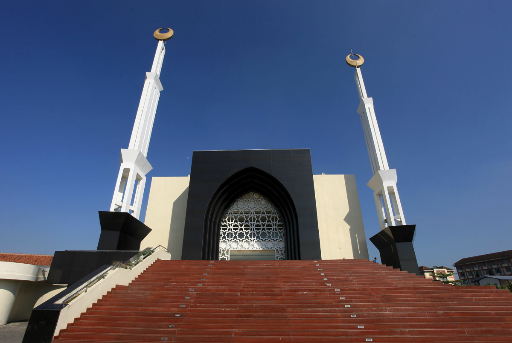

Train step: 2001
Total time: 2.1


In [ ]:
import time
start = time.time()

step = 1
for n in range(epochs):
    for m in range(steps_per_epoch):
        step += 1
        train_step
        print(".", end='', flush=True)
    display.clear_output(wait=True)
    display.display(tensor_to_image(image))
    print("Train step: {}".format(step))
    end = time.time()
print("Total time: {:.1f}".format(end-start))


# **Soal Praktik 2**

# **FIX ME 6: Gunakan Neural Style Transfer Pada Gambar Lain [Score: 20]**

**Style Image** - The Great Wave off Kanagawa

<img src="https://upload.wikimedia.org/wikipedia/commons/a/a5/Tsunami_by_hokusai_19th_century.jpg" width="500px"/>

https://upload.wikimedia.org/wikipedia/commons/a/a5/Tsunami_by_hokusai_19th_century.jpg

Apply to your content image (UAD building) with this **hyperparameters setting**:
*   Total variation weight = 20/30/40 (Pilih salah satu)
*   Adam learning rate = 0.001
*   Epoch = 20

In [ ]:
from google.colab import drive

# mounting dataset from gdrive
drive.mount('/content/gdrive', force_remount=True)

# this is the location of your image data
root_path = 'gdrive/My Drive/Deep Learning Labs/Responsi/Dataset Responsi/Dataset Responsi Deep Learning/'

# show the path
print("Path root:", root_path)

Mounted at /content/gdrive
Path root: gdrive/My Drive/Deep Learning Labs/Responsi/Dataset Responsi/Dataset Responsi Deep Learning/


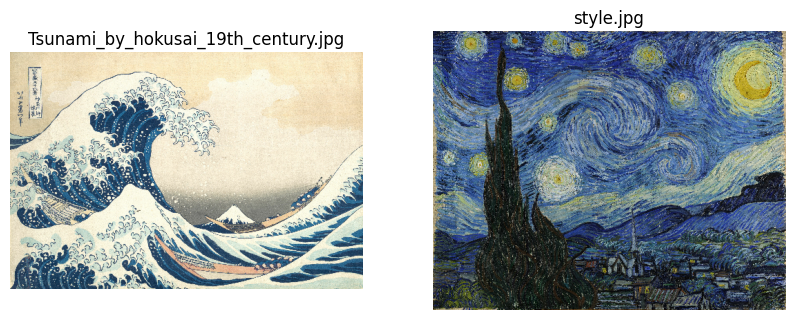

In [ ]:
content_path = os.path.join(root_path, 'Tsunami_by_hokusai_19th_century.jpg')
style_path = os.path.join(root_path, 'style.jpg')

content_image = load_img(content_path)
style_image = load_img(style_path)

plt.figure(figsize=(10, 15))
plt.subplot(1, 2, 1)
imshow(content_image, 'Tsunami_by_hokusai_19th_century.jpg')
plt.subplot(1, 2, 2)
imshow(style_image, 'style.jpg')

In [ ]:
# check the name of each layers on VGG16
vgg = tf.keras.applications.vgg16.VGG16(include_top=False, weights='imagenet')
vgg.summary()
print("Number of layers:", len(vgg.layers))


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Number of layers: 19


In [ ]:
# call the class to build style extractor
extractor = StyleContentModel(style_layers, content_layers)

results = extractor(tf.constant(content_image))

print('Styles:')
for name, output in sorted(results['style'].items()):
    print("  ", name)
    print("    shape: ", output.numpy().shape)
    print("    min: ", output.numpy().min())
    print("    max: ", output.numpy().max())
    print("    mean: ", output.numpy().mean())
    print()

print("Contents:")
for name, output in sorted(results['content'].items()):
    print("  ", name)
    print("    shape: ", output.numpy().shape)
    print("    min: ", output.numpy().min())
    print("    max: ", output.numpy().max())
    print("    mean: ", output.numpy().mean())

Styles:
   block1_conv1
    shape:  (1, 64, 64)
    min:  0.00024018766
    max:  75476.31
    mean:  947.875

   block2_conv1
    shape:  (1, 128, 128)
    min:  0.0
    max:  633500.1
    mean:  75633.13

   block4_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  1407288.4
    mean:  30795.678

   block5_conv1
    shape:  (1, 512, 512)
    min:  0.0
    max:  33479.086
    mean:  304.865

Contents:
   block5_conv2
    shape:  (1, 21, 31, 512)
    min:  0.0
    max:  511.95963
    mean:  6.6686425


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_342']
Received: inputs=Tensor(shape=(1, 344, 511, 3))
  warnings.warn(msg)


In [ ]:
# set up the hyperparamaters
style_weight=1e-2
content_weight=1e4
opt = tf.optimizers.Adam(learning_rate=0.001, beta_1=0.99, epsilon=1e-1)
total_variation_weight=50
# epoch
epochs = 20
steps_per_epoch = 100
# define the optimizer
opt = tf.optimizers.Adam(learning_rate=0.001, beta_1=0.99, epsilon=1e-1)



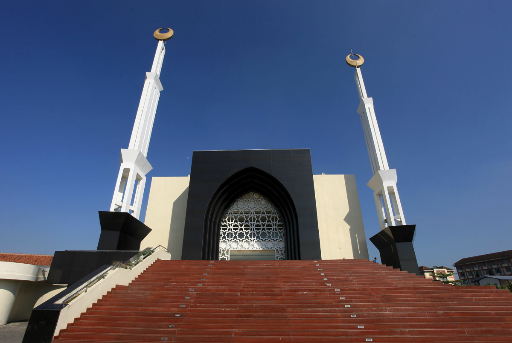

Train step: 2001
Total time: 2.8


In [ ]:
import time
start = time.time()

step = 1
for n in range(epochs):
    for m in range(steps_per_epoch):
        step += 1
        train_step
        print(".", end='', flush=True)
    display.clear_output(wait=True)
    display.display(tensor_to_image(image))
    print("Train step: {}".format(step))
    end = time.time()
print("Total time: {:.1f}".format(end-start))


# **Soal Teori**
1. Jelaskan secara singkat apa yang dimaksud dengan Convolutional Neural Network (CNN) dan sebutkan minimal dua bidang penerapannya. [Score: 5]
2. Apa peran dari Fully Connected Layer ( Dense Layer ) pada CNN dan mengapa lapisan ini sering diletakkan di bagian akhir arsitektur? [Score: 5]
3. Sebutkan dan jelaskan minimal dua metode yang dapat digunakan untuk mengurangi overfitting. [Score: 5]

## **Jawaban Soal Teori**

1. CNN adalah arsitektur dari neural network untuk model dalam penelitian image atau citra
pembagiannya yaitu sebagai klasifikasi ataupun akurasi pada penelitian

2. Peran dari Dense Layer untuk pembagian data atau layer sebelum di lakukan pemodelan klasifikasi citra menghindari noise citra pada penelitian

3. dense layers dan stop missing value pada saat pemodelan data dilatih berlangsung untuk mengurangi over fitting yang parah yang kesamaannya tidak sesuai dengan accuracy lossnya